In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = "../data/raw/pfas_data_hub"

df = pd.read_parquet(DATA_PATH)

print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

df.head()
df.info()
df.columns.tolist()
#documenter la structure du dataset, les types de données, les valeurs manquantes, les valeurs uniques, etc.
data_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum().values,
    "missing_rate_%": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique(dropna=True).values
})

display(data_dictionary.sort_values("missing_rate_%", ascending=False))
data_dictionary.to_csv("../reports/data_dictionary.csv", index=False)


Nombre de lignes : 942084
Nombre de colonnes : 21
<class 'pandas.DataFrame'>
RangeIndex: 942084 entries, 0 to 942083
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   category                942084 non-null  str    
 1   lat                     901132 non-null  float64
 2   lon                     901132 non-null  float64
 3   name                    942084 non-null  str    
 4   city                    477130 non-null  str    
 5   country                 940667 non-null  str    
 6   type                    942084 non-null  str    
 7   sector                  6012 non-null    str    
 8   source_type             942084 non-null  str    
 9   data_collection_method  910031 non-null  str    
 10  source_text             941525 non-null  str    
 11  source_url              920263 non-null  str    
 12  dataset_id              942084 non-null  int64  
 13  dataset_name            942084 non-

,column,dtype,missing_values,missing_rate_%,unique_values
sector,sector,str,936072,99.36,13
city,city,str,464954,49.35,34693
lon,lon,float64,40952,4.35,91863
lat,lat,float64,40952,4.35,88115
data_collection_method,data_collection_method,str,32053,3.40,6
date,date,str,23669,2.51,5726
source_url,source_url,str,21821,2.32,322
unit,unit,str,12642,1.34,4
matrix,matrix,str,12642,1.34,14
pfas_sum,pfas_sum,float64,12642,1.34,31013


In [ ]:
#comprendre la nature des lignes (ne representent pas forcément des mesures, il peuvent représenter mesures réelles,sites présuméssites industriels, utilisateurs connus de PFAS), Donc avant d’analyser les concentrations, il faut savoir quelles lignes sont vraiment des mesures.
category_counts = df["category"].value_counts(dropna=False)
display(category_counts)
#comprendre les sources de données, les méthodes de collecte, les types de sources
dataset_name_counts = df["dataset_name"].value_counts(dropna=False).head(10)
display(dataset_name_counts)
collection_method_counts = df["data_collection_method"].value_counts(dropna=False)
display(collection_method_counts)
source_type_counts = df["source_type"].value_counts(dropna=False)
display(source_type_counts)


In [ ]:
#vérifiés la qualité des données géographiques, cela nous aide si nous voulons faire produire des cartes et des analyses territoriales.
geo_cols = ["country", "city", "lat", "lon"]
geo_missing = df[geo_cols].isna().mean().sort_values(ascending=False) * 100
display(geo_missing)
invalid_coords = df[
    (df["lat"].notna()) &
    (df["lon"].notna()) &
    (
        (df["lat"] < -90) |
        (df["lat"] > 90) |
        (df["lon"] < -180) |
        (df["lon"] > 180)
    )
]

x = invalid_coords.shape
display(f"Nombre de coordonnées invalides : {x[0]}")
country_counts = df["country"].value_counts(dropna=False).head(10)
display(country_counts)


In [ ]:
#donne un résumé statistique des années disponibles et avoir si les données sont bien réparties dans le temps ou si elles sont concentrées sur certaines années. Cela peut influencer les analyses temporelles et les tendances que nous pourrons identifier.
df["year"].describe()
year_counts = df["year"].value_counts(dropna=False).sort_index()
display(year_counts)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
inf_date = df["date"].min(), df["date"].max()
display(f"Plage de dates : {inf_date[0]} à {inf_date[1]}")
#analyser la couverture temporelle du dataset pour vérifier si les données permettent une analyse par année ou par date exacte.
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["date"].min(), df["date"].max()
#identifier les types des milieu utilisés pour les mesures (eau, sol, air, etc.) et les unités de mesure utilisées pour les concentrations (ng/L, µg/kg, etc.). Cela permettra de mieux comprendre les données et de préparer les analyses ultérieures.
matrix_counts = df["matrix"].value_counts(dropna=False)
display(matrix_counts)
unit_counts = df["unit"].value_counts(dropna=False)
display(unit_counts)


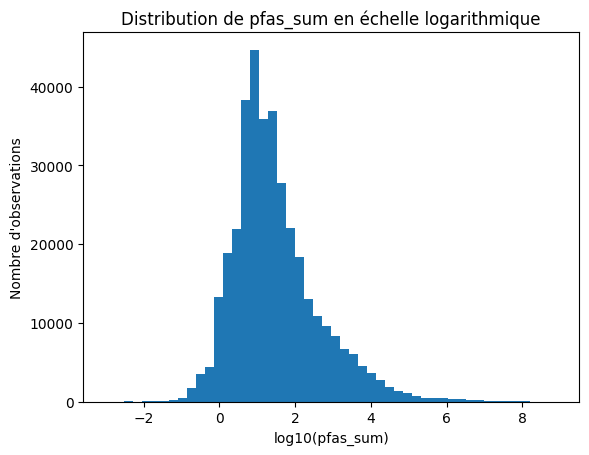

0                                                        []
1                                                        []
2                                                        []
3                                                        []
4                                                        []
                                ...                        
942079    [{"cas_id": "IGNORE", "unit": "ng/kg", "substa...
942080    [{"cas_id": "375-22-4", "unit": "ng/kg", "subs...
942081    [{"cas_id": "610800-34-5", "unit": "ng/kg", "s...
942082    [{"cas_id": "335-67-1", "unit": "ng/kg", "subs...
942083    [{"cas_id": "31506-32-8", "unit": "ng/kg", "su...
Name: pfas_values, Length: 942084, dtype: str

np.float64(1.3419)

In [4]:
pfas_positive = df[df["pfas_sum"] > 0]["pfas_sum"]

plt.hist(np.log10(pfas_positive), bins=50)
plt.title("Distribution de pfas_sum en échelle logarithmique")
plt.xlabel("log10(pfas_sum)")
plt.ylabel("Nombre d'observations")
plt.show()

#voir comment le champ est écrit
display(df["pfas_values"])
## Traitement des listes vides dans pfas_values
#La colonne `pfas_values` contient parfois des listes vides `[]`. Ces valeurs ne sont pas considérées comme nulles par Pandas, mais elles ne sont pas exploitables pour l’analyse détaillée par substance. Nous créons donc une colonne nettoyée `pfas_values_clean`, dans laquelle les listes vides sont remplacées par `NaN`.
df["pfas_values_clean"] = df["pfas_values"].copy()
df["pfas_values_clean"] = df["pfas_values_clean"].replace("[]", np.nan)
missing_rate_pfas_values = round(df["pfas_values_clean"].isna().mean() * 100, 4)

missing_rate_pfas_values

### Observation de la distribution logarithmique de `pfas_sum`

La majorité des observations se situe entre `log10(pfas_sum) = 0` et `log10(pfas_sum) = 2`, ce qui correspond approximativement à des valeurs de `pfas_sum` comprises entre 1 et 100. La distribution présente cependant une asymétrie vers la droite (queue à droite), avec quelques observations atteignant des valeurs très élevées.
Cette observation montre que `pfas_sum` est une variable fortement dispersée.
il est nécessaire d'identifier l'origine de ces valeurs extreme.

In [ ]:
cols_to_check = [
    "name", "country", "city", "year", "category",
    "matrix", "unit", "pfas_sum", "dataset_name"
]
display(df.sort_values("pfas_sum", ascending=False)[cols_to_check].head(10))


L’analyse des plus grandes valeurs de `pfas_sum` montre que les valeurs extrêmes ne sont pas aléatoires. Elles proviennent principalement de mesures réelles (`Measurement`), en particulier du dataset `Flanders DOV` pour des eaux souterraines en Belgique, ainsi que du dataset `France - ICPE` pour certains rejets industriels en France.
Ces valeurs ne doivent pas être supprimées automatiquement. Elles peuvent correspondre à des sites réellement critiques ou à des situations particulières liées à la matrice, à l’unité ou à la source de données. Elles seront donc conservées, mais analysées séparément dans les étapes suivantes.

In [ ]:
# 2. Synthèse par dataset, matrice et unité
summary_extreme = df.groupby(["dataset_name", "matrix", "unit"])["pfas_sum"].agg(
    count="count",
    median="median",
    q90=lambda x: x.quantile(0.90),
    q99=lambda x: x.quantile(0.99),
    max="max"
).sort_values("max", ascending=False)

summary_extreme.head(20)

L’analyse groupée par dataset, matrice et unité montre que les valeurs extrêmes de `pfas_sum` ne sont pas réparties de manière uniforme dans tout le dataset. Elles sont principalement associées à certains groupes, notamment `Flanders DOV / Groundwater / ng/l` et `France - ICPE / Wastewater / ng/l`.

On observe aussi que, dans plusieurs groupes, la médiane est beaucoup plus faible que la valeur maximale. Cela signifie que les valeurs extrêmes correspondent probablement à quelques observations particulières, et non au comportement général du groupe.

Cette analyse montre également que les données mélangent plusieurs matrices et unités : eau, sol, sédiments, biote, avec des unités comme `ng/l`, `ng/kg`, `ng/kg dw` ou `ng/kg fw`. Les concentrations ne doivent donc pas être comparées globalement sans tenir compte de la matrice et de l’unité.

on a vu plusieurs groupes avec une médiane égale à 0. Avant de transformer pfas_values, il faut comprendre ce que représentent ces zéros et pas interpreter directement que si pfas_sum = 0 ne signifie pas absence totale de contamination.

In [ ]:
zero_rate_global = round((df["pfas_sum"] == 0).mean() * 100, 2)
display(f"Taux de zéro global : {zero_rate_global}%")
zero_rate_by_group = df.groupby(["dataset_name", "matrix", "unit"])["pfas_sum"].apply(
    lambda x: (x == 0).mean() * 100
).sort_values(ascending=False)

display(zero_rate_by_group.head(20))


L’analyse montre que 60,31 % des lignes présentent une valeur `pfas_sum` égale à zéro. Ce taux élevé indique que les valeurs nulles occupent une place importante dans le dataset.
Ces zéros ne sont pas répartis de manière uniforme : ils sont très fréquents dans certains groupes définis par le dataset, la matrice et l’unité.

Cependant, ces zéros ne doivent pas être interprétés automatiquement comme une absence totale de contamination. Ils peuvent correspondre à des non-détections, à des valeurs inférieures à une limite de détection, à des valeurs non quantifiées ou à une convention de codage propre à certains datasets.

Cela signifie que les futures analyses ne doivent pas se baser uniquement sur une moyenne globale. Il faudra distinguer les mesures nulles des mesures positives, afin de calculer des indicateurs plus fiables comme le taux de détection, la moyenne hors zéros, la médiane, les percentiles et le maximum.

## Transformation de `pfas_values` en format long

La colonne `pfas_values` contient les valeurs détaillées des substances PFAS sous forme semi-structurée. Pour construire une future table de faits exploitable dans le Data Warehouse, il est nécessaire de transformer cette colonne en format long afin de préparer une table exploitable dans le futur Data Warehouse
Cette étape est centrale, car elle permet d’analyser les PFAS substance par substance avec ses informations associées

In [5]:
import json
import pandas as pd
import numpy as np

# 1. Garder uniquement les mesures avec pfas_values exploitable
df_measurements = df[
    (df["category"] == "Measurement") &
    (df["pfas_values_clean"].notna())
].copy()

print("Nombre de lignes Measurement exploitables :", df_measurements.shape[0])

# 2. Garder seulement les colonnes utiles
base_cols = [
    "dataset_id",
    "dataset_name",
    "name",
    "country",
    "city",
    "lat",
    "lon",
    "year",
    "date",
    "category",
    "matrix",
    "unit",
    "pfas_sum"
]

base_cols = [col for col in base_cols if col in df_measurements.columns]

df_work = df_measurements[base_cols + ["pfas_values_clean"]].copy()

print("Taille de la table de travail :", df_work.shape)

# 3. Parser la colonne JSON
def parse_pfas_values(x):
    if pd.isna(x):
        return []
    
    if isinstance(x, list):
        return x
    
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            return []
    
    return []

df_work["pfas_values_parsed"] = df_work["pfas_values_clean"].apply(parse_pfas_values)

display(df_work["pfas_values_parsed"].apply(len).describe())

# 4. Supprimer la colonne texte lourde avant explode
df_work = df_work.drop(columns=["pfas_values_clean"])

# 5. Transformer une ligne contenant plusieurs substances en plusieurs lignes
df_long = df_work.explode("pfas_values_parsed", ignore_index=True)

print("Taille après explode :", df_long.shape)

# 6. Transformer le JSON en colonnes
pfas_details = pd.json_normalize(df_long["pfas_values_parsed"])

df_long = df_long.drop(columns=["pfas_values_parsed"])

df_pfas_long = pd.concat(
    [
        df_long.reset_index(drop=True),
        pfas_details.add_prefix("pfas_").reset_index(drop=True)
    ],
    axis=1
)

print("Taille finale :", df_pfas_long.shape)

display(df_pfas_long.head())

Nombre de lignes Measurement exploitables : 929442
Taille de la table de travail : (929442, 14)


count    929442.000000
mean         23.165422
std          16.654867
min           1.000000
25%           8.000000
50%          22.000000
75%          35.000000
max          96.000000
Name: pfas_values_parsed, dtype: float64

Taille après explode : (21530916, 14)
Taille finale : (21530916, 19)


,dataset_id,dataset_name,name,country,city,lat,lon,year,date,category,matrix,unit,pfas_sum,pfas_cas_id,pfas_unit,pfas_substance,pfas_value,pfas_isomer,pfas_less_than
0,10,15 textile facilities emitting PFAS,Maes,Belgium,Zwevegem,50.808932,3.352552,2018.0,NaN,Measurement,Surface water,ng/l,130.0,335-67-1,ng/l,PFOA,90.0,NaN,NaN
1,10,15 textile facilities emitting PFAS,Maes,Belgium,Zwevegem,50.808932,3.352552,2018.0,NaN,Measurement,Surface water,ng/l,130.0,1763-23-1,ng/l,PFOS,40.0,NaN,NaN
2,10,15 textile facilities emitting PFAS,Tarkett,Belgium,Dendermonde,51.016507,4.088303,2017.0,NaN,Measurement,Surface water,ng/l,200.0,335-67-1,ng/l,PFOA,200.0,NaN,NaN
3,10,15 textile facilities emitting PFAS,Ververijen Escotex,Belgium,Deinze,51.042282,3.548967,2016.0,NaN,Measurement,Surface water,ng/l,42400.0,335-67-1,ng/l,PFOA,41400.0,NaN,NaN
4,10,15 textile facilities emitting PFAS,Ververijen Escotex,Belgium,Deinze,51.042282,3.548967,2016.0,NaN,Measurement,Surface water,ng/l,42400.0,1763-23-1,ng/l,PFOS,500.0,NaN,NaN
